In [1]:
import pandas as pd
import numpy as np

In [14]:
data=pd.read_csv(r"Churn_Modelling.csv")
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [15]:
data['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [16]:
data=data.drop(['RowNumber','CustomerId','Surname'],axis=1)

data=pd.get_dummies(data,columns=['Geography','Gender'],)
data.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,True,False,False,True,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,False,True,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,True,False,False,True,False
3,699,39,1,0.00,2,0,0,93826.63,0,True,False,False,True,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,False,True,True,False


In [17]:
X=data.drop(['Exited'],axis=1)
X
y=data["Exited"]
y

0       1
1       0
2       1
3       0
4       0
       ..
9995    0
9996    0
9997    1
9998    1
9999    0
Name: Exited, Length: 10000, dtype: int64

In [18]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=43
)

In [19]:
from sklearn.preprocessing import StandardScaler

sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [ ]:
# from sklearn.linear_model import LogisticRegression
# model=LogisticRegression(class_weight='balanced')

# model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [ ]:
# y_pred=model.predict(X_test)
# y_pred

array([1, 0, 1, ..., 0, 1, 1], shape=(2000,))

In [ ]:
# from sklearn.metrics import accuracy_score,classification_report
# print("Accuracy_score =",accuracy_score(y_test,y_pred))
# print("Classification report =",classification_report(y_test,y_pred))

Accuracy_score = 0.713
Classification report =               precision    recall  f1-score   support

           0       0.89      0.72      0.80      1588
           1       0.39      0.67      0.49       412

    accuracy                           0.71      2000
   macro avg       0.64      0.70      0.65      2000
weighted avg       0.79      0.71      0.74      2000



In [ ]:
# y_prob = model.predict_proba(X_test)[:,1]

# from sklearn.metrics import roc_auc_score
# print("ROC-AUC score =", roc_auc_score(y_test, y_prob))

ROC-AUC score = 0.752627411899929


In [ ]:
# from sklearn.ensemble import RandomForestClassifier

# RFC=RandomForestClassifier(class_weight='balanced',
#                            n_estimators=200,
#                            max_depth=10,
#                            min_samples_split=5)
# RFC.fit(X_train,y_train)
# RFC_pred=RFC.predict(X_test)

In [ ]:
# print("Accuracy score for RFC =",accuracy_score(y_test,RFC_pred))
# print("Classification report for RFC =",classification_report(y_test,RFC_pred))
# y_prob = RFC.predict_proba(X_test)[:,1]

# from sklearn.metrics import roc_auc_score
# print("ROC-AUC score for RFC =", roc_auc_score(y_test, y_prob))

Accuracy score for RFC = 0.8395
Classification report for RFC =               precision    recall  f1-score   support

           0       0.91      0.89      0.90      1588
           1       0.60      0.66      0.63       412

    accuracy                           0.84      2000
   macro avg       0.75      0.77      0.76      2000
weighted avg       0.85      0.84      0.84      2000

ROC-AUC score for RFC = 0.8643604338362965


In [ ]:
# import pandas as pd

# importance = pd.Series(RFC.feature_importances_, index=X.columns)
# importance.sort_values(ascending=False)

Age                  0.325172
NumOfProducts        0.204589
Balance              0.115234
EstimatedSalary      0.078390
CreditScore          0.077730
IsActiveMember       0.064880
Geography_Germany    0.045476
Tenure               0.045092
Gender_Male          0.024827
HasCrCard            0.009914
Geography_Spain      0.008697
dtype: float64

In [20]:
from sklearn.metrics import accuracy_score,classification_report
from xgboost import XGBClassifier
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])
XGB=XGBClassifier(
                n_estimators=200,
                max_depth=6,
                learning_rate=0.1,
                scale_pos_weight=scale_pos_weight,
                random_state=42,
                eval_metric='logloss')
XGB.fit(X_train,y_train)
XGB_pred=XGB.predict(X_test)

In [21]:
print("Accuracy score for XGB =",accuracy_score(y_test,XGB_pred))
print("Classification report for XGB =",classification_report(y_test,XGB_pred))
y_prob_XGB = XGB.predict_proba(X_test)[:,1]

from sklearn.metrics import roc_auc_score
print("ROC-AUC score for XGB =", roc_auc_score(y_test, y_prob_XGB))

Accuracy score for XGB = 0.8245
Classification report for XGB =               precision    recall  f1-score   support

           0       0.91      0.87      0.89      1588
           1       0.56      0.67      0.61       412

    accuracy                           0.82      2000
   macro avg       0.74      0.77      0.75      2000
weighted avg       0.84      0.82      0.83      2000

ROC-AUC score for XGB = 0.8506838301826809


In [22]:
import pandas as pd

importance = pd.Series(XGB.feature_importances_, index=X.columns)
importance.sort_values(ascending=False)

NumOfProducts        0.282022
IsActiveMember       0.171718
Age                  0.123828
Geography_Germany    0.083026
Balance              0.060827
Gender_Female        0.049951
Geography_France     0.047333
Geography_Spain      0.041819
CreditScore          0.036502
Tenure               0.034737
EstimatedSalary      0.034653
HasCrCard            0.033584
Gender_Male          0.000000
dtype: float32

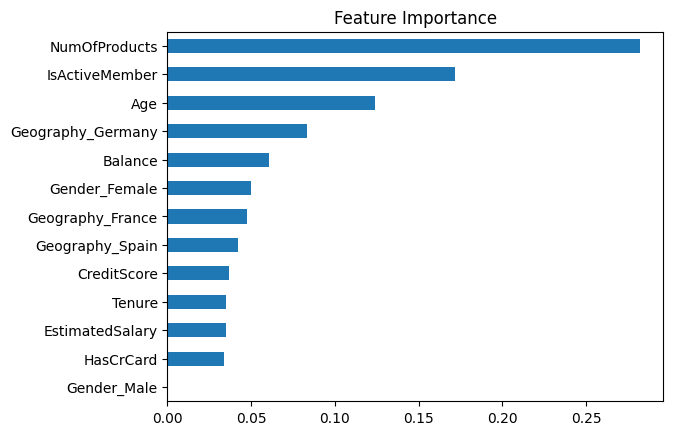

In [23]:
import matplotlib.pyplot as plt

importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

In [24]:
data.to_csv(r"D:\Ashish Workshop\All data\ML & DL\curn_prediction\encoded_file.csv",index=False)

In [ ]:
import pickle

pickle.dump(XGB, open('churn_model.pkl', 'wb'))

: 